# Изучение рынка заведений общественного питания Москвы

- Автор: Смирнов Александр Викторович
- Дата: 10.03.2025

###  Цели и задачи проекта
**Цель**: Провести исследовательский анализ рынка общественного питания города Москвы, чтобы помочь заказчику, инвесторами из фонда Shut Up and Take My Money, определиться с типом, местоположением и ценовой категорией будущего заведения общественного питания в Москве.

**Задачи**:
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных
4. Сформулировать выводы по проведённому анализу.

### Описание данных

**Данные**: В нашем распоряжении 2 файла `rest_info.csv` содержит информацию о заведениях общественного питания и `rest_price.csv` с информацией о среднем чеке в заведениях общественного питания:

**Описание `rest_price.csv`**:

- `name` — название заведения
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
0 — заведение не является сетевым;
1 — заведение является сетевым.
- `seats` — количество посадочных мест.

**Описание `/datasets/rest_price.csv`**:

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
«Средний счёт: 1000–1500 ₽»;
«Цена чашки капучино: 130–220 ₽»;
«Цена бокала пива: 400–600 ₽».
и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца
- `avg_bill`, начинающихся с подстроки «Средний счёт»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца 'avg_bill', начинающихся с подстроки «Цена одной чашки капучино»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации

## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек pandas, matplotlib и seaborn, а также phik для построения матрицы корреляции.

In [490]:
# Импортируем библиотеки
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import warnings
warnings.filterwarnings('ignore')

Загрузим датасеты `rest_info.csv` и `rest_price.csv`. Будем использовать  Данные датасетов сохраним в двух переменных: df_rest_info и df_rest_price.

In [ ]:
df_rest_info = pd.read_csv('rest_info.csv')
df_rest_price= pd.read_csv('rest_price.csv')

Познакомимся с данными датасета `df_rest_info` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [492]:
df_rest_info.head(5)

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [493]:
df_rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых содержится информация о заведениях общественного питания.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов уже приведены к одному виду, snake case.
- Данные содержат числовые и строковые значения, они хранятся в типах данных `float64(2)`, `int64(1)`, `object(6).
- Пропуски содержатся только в двух столбцах `hours` и `seats`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `rest_price.csv`. </font>

In [494]:
df_rest_price.head(5)

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [495]:
df_rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых содержится информация о среднем чеке в заведениях общественного питания. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов уже приведены к единому виду, snake case.
- Типы данных соответствуют содержимому.
- Пропусков на первый взгляд достаточно много, особенно в столбце `middle_coffee_cup`.
- Значения в столбцах соответствуют описанию.</font>

---

### Промежуточный вывод

Первичное знакомство показывает, что данные `rest_info.csv` хорошего качества — в них практически нет пропущенных значений, а сами данные соответствуют описанию и выглядят корректными. А вот про данные `rest_price.csv`, нельзя сказать, что они хорошего качества, в них много пропусков. Столбец `price` представлен как категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее. `avg_bill`, хранит средний чек как диапазон стоимости в заказе.


Настало время следующего этапа — предобработки данных

### Подготовка единого датафрейма

Для исследования нам понадобится единый датасет с максимальным объемом данных, поэтому объединим датафреймы с информацией `df_rest_info` и ценами `df_rest_price` по левому типу 

In [496]:
df = pd.merge(df_rest_info, df_rest_price, on= 'id', how= 'left')

df.head(5)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [497]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Объединенный датафрейм имеет 8406 строк и 13 столбцов. Информация обо всех заведениях общественного питания сохранилась.

### Оптимизируем типы данных

- Тип данных в столбце `price`, содержащий ценовые категории - 'object' можно привести к типу 'category' 
- Столбцы `category` и `district` содержат ограниченное число значений, поэтому их возможно также привести к типу данных 'category'
- Представленные данные содержат числовые значения в столбцах `middle_coffee_cup`, `middle_avg_bill`, `rating`, `chain`, `seats` и хранятся в типах данных int64 или float64. Столбец chain представлен бинарными значениями. Так как значения в этих столбцах невысокие, то можно понизить разрядность.

In [498]:
# Оптимизируем целочисленный тип данных в столбце `chain`
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')
# Приводим значения в `seats` к целочисленному типу
df['seats'] = df['seats'].astype('Int32')
# Приводим значения в `middle_avg_bill` к целочисленному типу
df['middle_avg_bill'] = df['middle_avg_bill'].astype('Int32')
# Приводим значения в `middle_coffee_cup` к целочисленному типу
df['middle_coffee_cup'] = df['middle_coffee_cup'].astype('Int32')

# Приводим столбцы с ограниченным набором значений к типу данных 'category'
for column in ['price','category','district']:
    df[column] = df[column].astype('category')

Типы данных были успешно оптимизированы с понижением размерности целочисленных данных.

### Проверяем наличие пропусков в данных

При первичном анализе мы обнаружили пропуски в столбце `hours` датафрейма df. Узнаем абсолютное и относительное количество пропусков в общем датасете.

In [499]:
missing = (pd.DataFrame({'Количество пропусков': df.isnull().sum(), 'Доля пропусков': df.isnull().mean().round(4)}).style.background_gradient(cmap='coolwarm'))

missing

,Количество пропусков,Доля пропусков
id,0,0.000000
name,0,0.000000
category,0,0.000000
address,0,0.000000
district,0,0.000000
hours,536,0.063800
rating,0,0.000000
chain,0,0.000000
seats,3611,0.429600
price,5091,0.605600


В датафрейме `df` обнаружено много пропусков в столбце:
- `seats` — это 43% данных, столбец содержит информацию о количестве мест в заведении. Пропуски могут быть обусловлены несколькими причинами:
  - Количество посадочных мест может меняться в зависимости от сезона, ремонта или других факторов, и данные могли устареть или просто отсутствует на этапе сбора данных.
  - В процессе обновления информации о заведениях могут пропускать этот параметр, особенно если он не считается приоритетным.

- `price` — это 60% данных, в столбце содержится информация о категории цен заведения (например, «средняя», «высокая»). Причины пропуска могут включать:
  - Информация о цене заведения может обновляться реже, чем другая информация, поскольку заведение не меняет свою категорию часто.
  - Заведение может предлагать блюда разного уровня стоимости, что затрудняет однозначную оценку его категории.

- `avg_bill` — это 55% данных, столбец хранит строку с указанием средней стоимости заказа. Причина пропуска может заключаться в следующем:
  - Средняя стоимость может отсутствовать, если заведение не предоставляет такую информацию.
  - Возможно, данные были неправильно обработаны, и средняя стоимость не была извлечена корректно.

- `middle_avg_bill` — это 63% данных, столбец содержит числовое значение средней стоимости заказа, рассчитанное на основе данных из столбца `avg_bill`. Пропуски могут возникать по следующим причинам:
  - Поскольку расчет производится на основе `avg_bill`, пустые значения в этом столбце приводят к пропускам в middle_avg_bill.
  - Отсутствие точного диапазона цен в avg_bill может препятствовать правильному вычислению медианного значения.

- `middle_coffee_cup` — это 94% данных, столбец содержит цену одной чашки капучино, рассчитываемую на основе данных из столбца `avg_bill`. Основная причина таких больших пропусков заключается в следующем:
  - Столбец заполняется только для записей, где указана цена капучино. Многие заведения могут не указывать эту конкретную информацию, что объясняет высокий процент пропусков.
  - Если в исходных данных отсутствуют конкретные сведения о цене капучино, то в результате будут пропуски.

 Количество пропусков достаточно большое, чтобы их просто удалить.

Проверим данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуем данные в текстовых столбцах, например с названием заведения.

In [500]:
df.duplicated().sum()

0

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по `id` клиентов должны быть уникальными, то есть каждая строка в данных — уникальный клиент.

In [501]:
df['name'] = df['name'].str.lower()

In [502]:
df.duplicated(subset= 'id').sum()

0

In [503]:
print(f"Найдено: {df.duplicated(subset= ['name', 'address']).sum()} дубликата")

df = df.drop_duplicates(subset= ['name', 'address'])

print(f"Найдено: {df.duplicated(subset= ['name', 'address']).sum()} дубликатов, после удаления")


Найдено: 3 дубликата
Найдено: 0 дубликатов, после удаления


In [504]:
df['price'].unique()

[NaN, 'выше среднего', 'средние', 'высокие', 'низкие']
Categories (4, object): ['выше среднего', 'средние', 'высокие', 'низкие']

Тут тоже всё хорошо — каждая строка соответствует уникальному клиенту.

Создаем столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [505]:
df['is_24_7'] = (df['hours'].str.contains('ежедневно') & df['hours'].str.contains('круглосуточно'))

print('Число заведений круглосуточного типа:', df['is_24_7'].sum())
print('Процент заведений круглосуточного типа от общего числа заведений:', round(df['is_24_7'].sum()/df.shape[0], 3)*100, '%' )

Число заведений круглосуточного типа: 730
Процент заведений круглосуточного типа от общего числа заведений: 8.7 %


In [506]:
df_test = df[['avg_bill', 'middle_avg_bill']]

df_test['avg_bool'] = df['avg_bill'].str.contains('Средний счёт')

df_test[df_test['avg_bool'] == True].isna().sum()

avg_bill           0
middle_avg_bill    0
avg_bool           0
dtype: int64

Решил проверить, заполнение столбца по условию из задания, все верно. `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»

---

### Промежуточный вывод

После анализа данных было выявлено значительное количество пропусков в нескольких столбцах и сделал промежуточные выводы.

Пропущенные данные:
- `seats`: 43% данных пропущено. Это может быть связано с изменениями количества посадочных мест или отсутствием актуальных данных на момент сбора.
- `price`: 60% данных пропущено. Категория цен заведений может обновляться редко или не предоставляться в явной форме.
- `avg_bill`: 55% данных пропущено. Средняя стоимость заказа может отсутствовать, если заведение не предоставляет такие данные.
- `middle_avg_bill`: 63% данных пропущено. Эти пропуски зависят от наличия данных в столбце `avg_bill`.
- `middle_coffee_cup`: 94% данных пропущено. Высокая доля пропусков обусловлена отсутствием конкретных сведений о цене капучино.

Дубликаты:
- Датафрейм не содержит полных дубликатов строк.
- Уникальность идентификаторов клиентов (id) проверена и подтвердилась, что каждая строка представляет собой  уникальные записи.

Заполнение столбцов:
- Проведена проверка заполнения столбца `middle_avg_bill` по условию задания, результаты соответствуют ожиданиям.  Этот столбец содержит числовые оценки среднего чека, указанные только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт».

Учитывая высокую долю пропусков, удаление данных может существенно повлиять на объем выборки.

## Исследовательский анализ данных

---

### Задача 1

В датасете представлены данные категориального типа в столбцах `category`, `chain`, `price`
Исследуем количество объектов общественного питания по каждой категории

In [507]:
df_cat= pd.DataFrame({'Количество': df['category'].value_counts(), 'Процент': round(df['category'].value_counts(normalize=True), 3)*100}).style.background_gradient(cmap='coolwarm')
df_cat

,Количество,Процент
кафе,2377,28.300000
ресторан,2042,24.300000
кофейня,1413,16.800000
"бар,паб",764,9.100000
пиццерия,633,7.500000
быстрое питание,603,7.200000
столовая,315,3.700000
булочная,256,3.000000


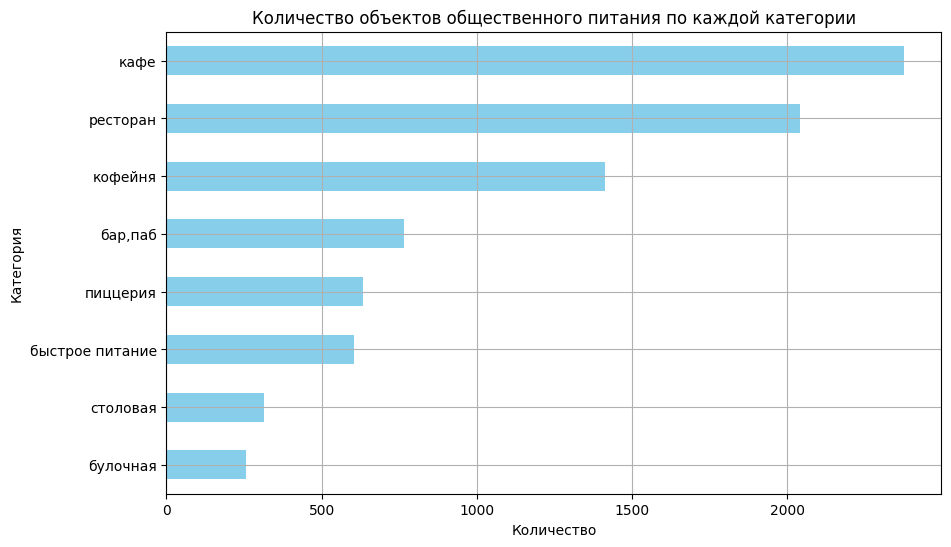

In [508]:
df['category'].value_counts().sort_values(ascending=True).plot(kind= 'barh',
                                   title= 'Количество объектов общественного питания по каждой категории',
                                   ylabel= 'Категория',
                                   color= 'skyblue',
                                   figsize= (10, 6))
plt.xlabel('Количество')
plt.grid()
plt.show()

Выводы:
- Рестораны, кофейни и кафе занимают лидирующие позиции, составляя основу рынка общественного питания.
- Бары и пиццерии также востребованы, но их доля меньше.
- Заведения типа столовых, фаст-фуда и булочных встречаются значительно реже, что отражает меньшую популярность этих форматов.

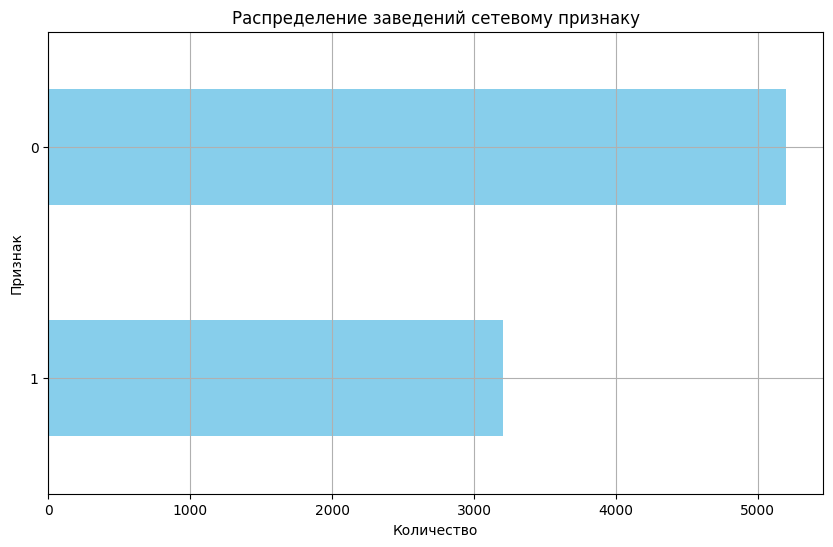

In [509]:
df['chain'].value_counts().sort_values(ascending=True).plot(kind= 'barh',
                                   title= 'Распределение заведений сетевому признаку',
                                   ylabel= 'Признак',
                                   color= 'skyblue',
                                   figsize= (10, 6))
plt.xlabel('Количество')
plt.grid()
plt.show()

Количество несетевых заведений(5199) превышает число сетевых (3203)

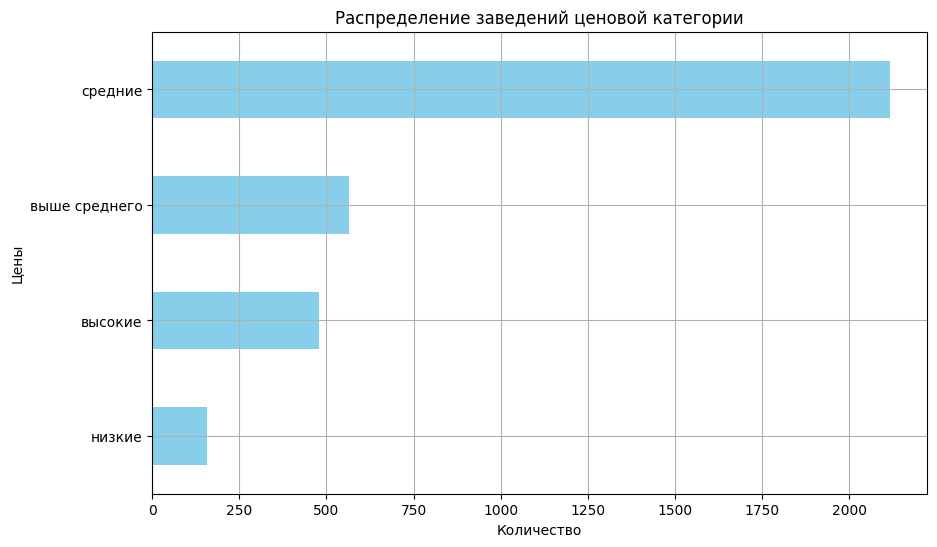

In [510]:
df['price'].value_counts().sort_values(ascending=True).plot(kind= 'barh',
                                   title= 'Распределение заведений ценовой категории',
                                   ylabel= 'Цены',
                                   color= 'skyblue',
                                   figsize= (10, 6))
plt.xlabel('Количество')
plt.grid()
plt.show()

С большим отрывом преобладают заведения ОП среднего ценового диапазона (2117). Заведений с низкими ценами меньше всего (156)

---

### Задача 2

Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

Выводим число и долю заведений по округам

In [511]:
df['district'].value_counts()

Центральный административный округ         2242
Северный административный округ             899
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

Визуализируем распределение на линейчатой диаграмме

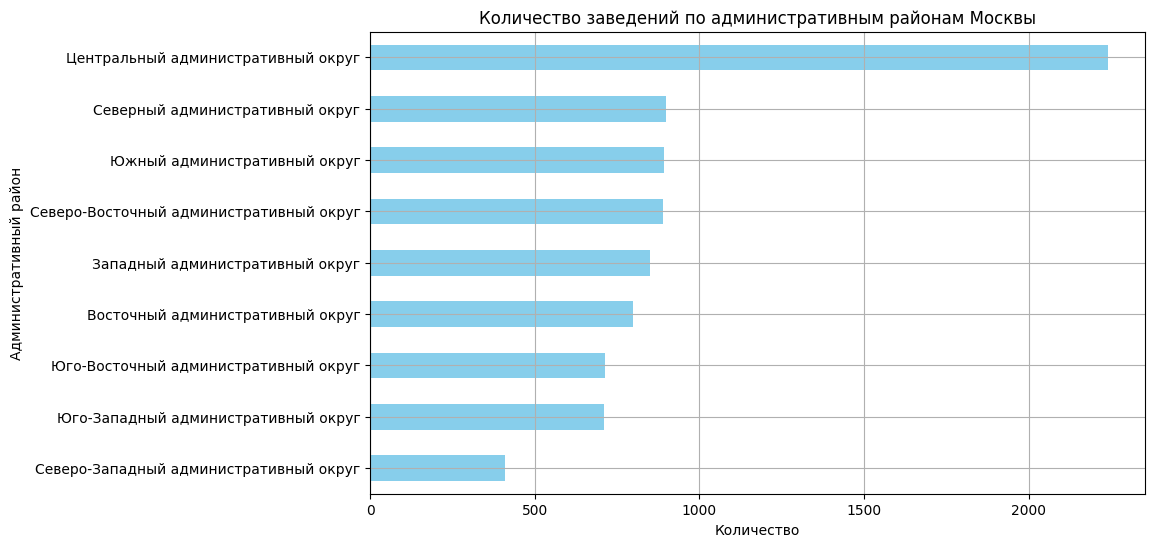

In [512]:
df['district'].value_counts().sort_values(ascending=True).plot(kind= 'barh',
                                   title= 'Количество заведений по административным районам Москвы',
                                   ylabel= 'Административный район',
                                   color= 'skyblue',
                                   figsize= (10, 6))
plt.xlabel('Количество')
plt.grid()
plt.show()

Выводы:
- Центральный административный округ имеет наибольшее количество заведений, что связано с его ролью делового и культурного центра города.
- Северные, Южный и Северо-Восточный округа также демонстрируют значительное количество заведений, что может быть обусловлено плотностью населения и развитой инфраструктурой.
- Западный, Восточный, Юго-Западный и Юго-Восточный округа имеют еще более меньшее количество.
- Северо-Западный округ имеет наименьшее количество заведений, что может быть связано с менее развитой инфраструктурой.

Выведем общую информацию о заведениях а Центральном административном огруге ЦАО

In [513]:
df_central = df[df['district'] == 'Центральный административный округ']

df_central['category'].value_counts()

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

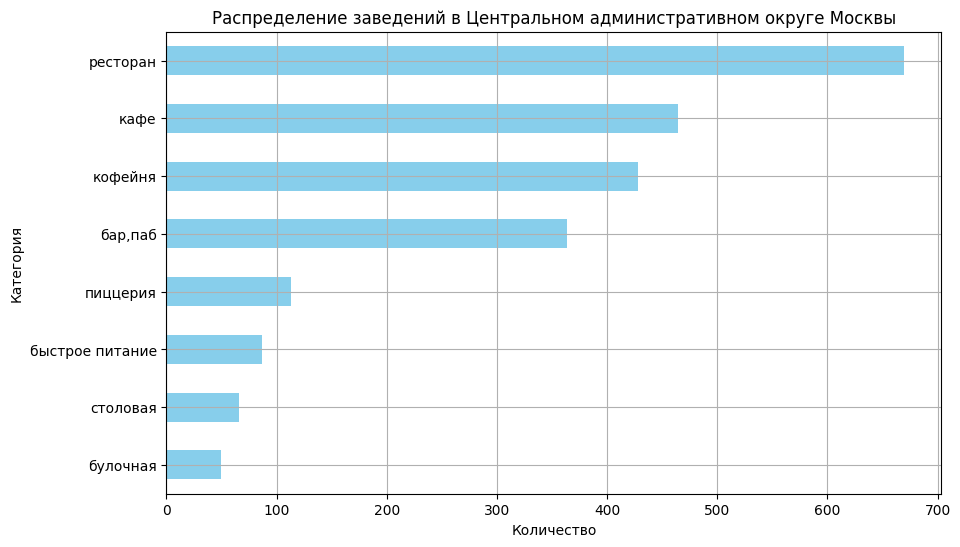

In [514]:
df_central['category'].value_counts().sort_values(ascending=True).plot(kind= 'barh',
                                   title= 'Распределение заведений в Центральном административном округе Москвы',
                                   ylabel= 'Категория',
                                   color= 'skyblue',
                                   figsize= (10, 6))
plt.xlabel('Количество')
plt.grid()
plt.show()

Выводы:
- Рестораны, бары/пабы и кофейни занимают лидирующие позиции по количеству заведений.
- Кафе и пиццерии также достаточно распространены, что подтверждает интерес потребителей к легкому питанию и итальянской кухне.
- Заведения быстрого питания, столовые и булочные занимают меньшую долю рынка, что может отражать их более специализированный характер и ограниченный круг клиентов.

---

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. 

Выведем общую информацию о заведениях

In [515]:
print('Общее количество заведений общественного питания:', df.shape[0])
print('Количество несетевых заведений ОП:', df.shape[0] - df['chain'].sum())
print('Количество сетевых заведений ОП:', df['chain'].sum())
print('Процент сетевых заведений ОП от общего числа заведений:', round(df['chain'].sum()/df.shape[0], 3)*100,'%')

Общее количество заведений общественного питания: 8403
Количество несетевых заведений ОП: 5200
Количество сетевых заведений ОП: 3203
Процент сетевых заведений ОП от общего числа заведений: 38.1 %


Несетевых заведений больше, процент сетевых составляет 38.1 % от общего числа объектов ОП

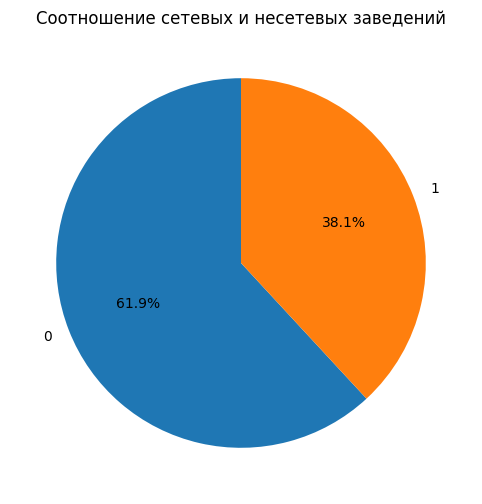

In [516]:
values = df['chain'].value_counts()
labels = values.index

plt.figure(figsize=(10, 6)) 

plt.pie(values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90)      

plt.title('Соотношение сетевых и несетевых заведений')

plt.show()

Несетевые заведения преобладают над сетевыми, имея значительное преимущество по численности. Несетевых магазинов насчитывается 5200, тогда как сетевых — 3203.

In [517]:
set_df = df[df['chain']==1]
not_set_df = df[df['chain']==0]

chain_count = (pd.DataFrame({'Кол-во сетевых': set_df['category'].value_counts(), 
                             'Кол-во несетевых':not_set_df['category'].value_counts(),
                             'Доля сетевых от несетевых': 
                             round(set_df['category'].value_counts()/not_set_df['category'].value_counts(), 2),
                             'Процент сетевых': round(set_df['category'].value_counts()/(set_df['category'].value_counts()+not_set_df['category'].value_counts()), 3)*100
                            }).sort_values(by = 'Доля сетевых от несетевых', ascending=False)
           .style.background_gradient(cmap='coolwarm'))

chain_count

,Кол-во сетевых,Кол-во несетевых,Доля сетевых от несетевых,Процент сетевых
булочная,157,99,1.590000,61.300000
пиццерия,330,303,1.090000,52.100000
кофейня,720,693,1.040000,51.000000
быстрое питание,232,371,0.630000,38.500000
ресторан,729,1313,0.560000,35.700000
кафе,779,1598,0.490000,32.800000
столовая,88,227,0.390000,27.900000
"бар,паб",168,596,0.280000,22.000000


Визуализируем распределение категорий в зависимости от сетевого признака в виде линейчатой диаграммы

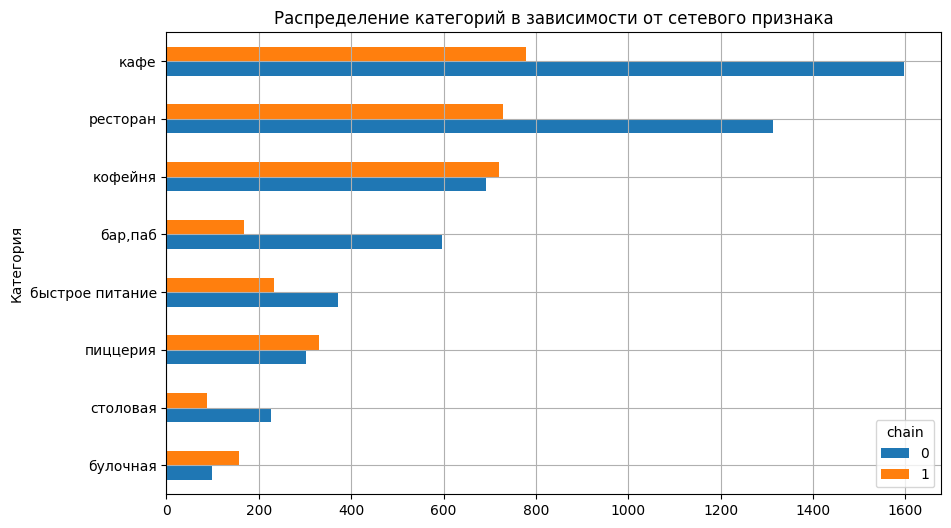

In [518]:
grouped = df.groupby('category')['chain'].value_counts().unstack(fill_value=0).sort_values(by=0)

grouped.plot(kind='barh',
               title=f'Распределение категорий в зависимости от сетевого признака',
               legend=True,
               ylabel='Количество заведений',
               xlabel='Категория',
               rot=0,
               figsize=(10, 6))
plt.grid()
plt.show()

Наиболее распространенные сетевые заведения кафе(779), рестораны(729) и кофейни(720)
Чаще являются сетевыми булочные(61,3 %), пиццерии(52,1 %) и кофейни(51 %)

Визуализируем распределение заведений по округам в разрезе сетевого признака

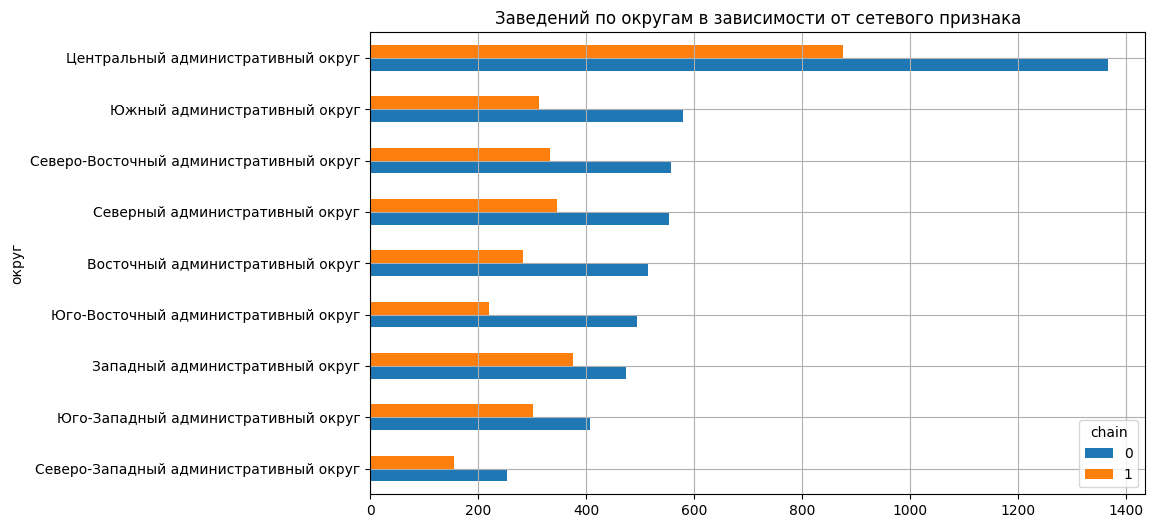

In [519]:
grouped = df.groupby('district')['chain'].value_counts().unstack(fill_value=0).sort_values(by=0)

grouped.plot(kind='barh',
               title=f'Заведений по округам в зависимости от сетевого признака',
               legend=True,
               ylabel='Количество заведений',
               xlabel='округ',
               rot=0,
               figsize=(10, 6))
plt.grid()
plt.show()

Юго-восточный, Восточный и Южный - административные округа, в которых наименьшая доля сетевых заведений по сравнению с несетевыми

Посчитаем процент сетевых зыведений по округам

In [520]:
grouped = df.groupby('district')['chain'].value_counts().unstack(fill_value=0).sort_values(by=0)

percent_set = round(grouped[1]/(grouped[1]+grouped[0]), 3)*100

percent_set.sort_values()

district
Юго-Восточный административный округ       30.8
Южный административный округ               35.0
Восточный административный округ           35.5
Северо-Восточный административный округ    37.4
Северо-Западный административный округ     38.1
Северный административный округ            38.5
Центральный административный округ         39.0
Юго-Западный административный округ        42.6
Западный административный округ            44.2
dtype: float64

Самые неразвитые по сетевому признаку заведений ОП округи Москвы `юго-восточный` 30.8 %, `южный` 35.0 %, `восточный` 35.5 %


In [521]:
df_chain = df[df['chain'] == 1]

In [522]:
df_chain_share = (df_chain.groupby('category')['chain'].count() / df.groupby('category')['chain'].count()).round(2).reset_index().sort_values(by= 'chain', ascending= False)

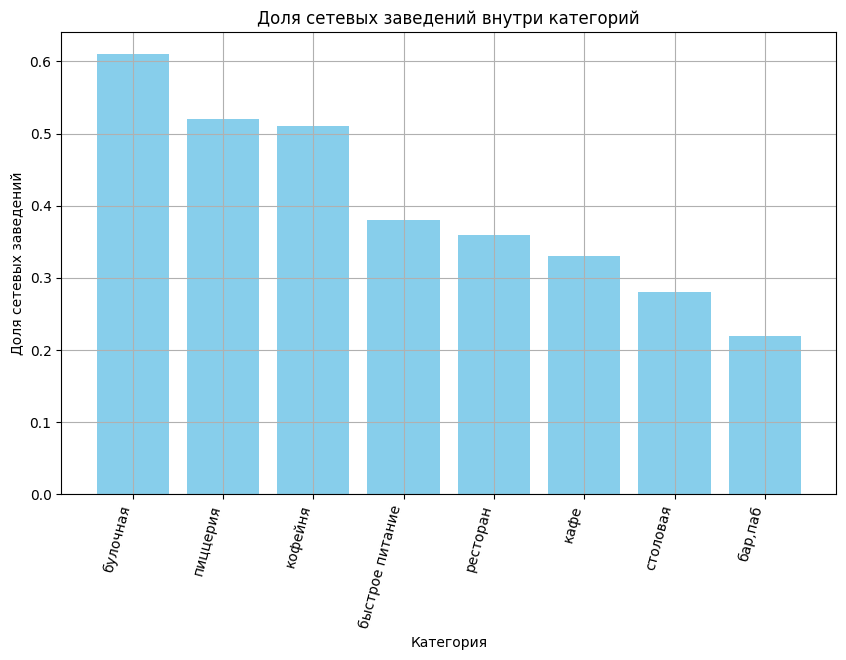

In [523]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(df_chain_share['category'], df_chain_share['chain'], color= 'skyblue')

ax.set_xticklabels(df_chain_share['category'], rotation=75, ha='right', va='top')
ax.set_xlabel('Категория')
ax.set_ylabel('Доля сетевых заведений')

ax.set_title('Доля сетевых заведений внутри категорий')

plt.grid()
plt.show()

Вывод:
- В большинстве категорий количество несетевых заведений превышает сетевые. 
- Однако есть категории, где сетевые заведения либо доминируют, либо близки по количеству к несетевым.

---

### Задача 4

Исследуем количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводим подходящими визуализациями.


Посмотрим статистические данные столбца `seats`

In [524]:
df['seats'].describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Для начала, посмотрим на значения, которые мы имеем:
- Среднее значение (mean) = 109.42
- Стандартное отклонение (std) = 114.7
- Максимальное значение (max) = 1288

Максимальное значение в данных — 1288. Это значение значительно превышает верхнюю границу в 95 и 99 процентиля, что указывает на наличие выброса.


In [525]:
outliers = df['seats'].quantile(0.95)

# Отбираем данные, оставляя значения меньше найденного порога выбросов
new_df = df.loc[df['seats'] < outliers]

new_df['seats'].describe()

count    4550.000000
mean       88.127692
std        70.859617
min         0.000000
25%        40.000000
50%        70.000000
75%       120.000000
max       306.000000
Name: seats, dtype: float64

Отбираем данные, оставляя значения меньше найденного порога выбросов:
- Среднее значение (mean) = 90.61
- Стандартное отклонение (std) = 70.37
- Максимальное значение (max) = 310

Поскольку минимальное значение равно 0, оно находится внутри допустимого диапазона, так как отрицательные значения в данном контексте недопустимы. Однако максимальное значение (310), следовательно, выбросов среди данных нет.

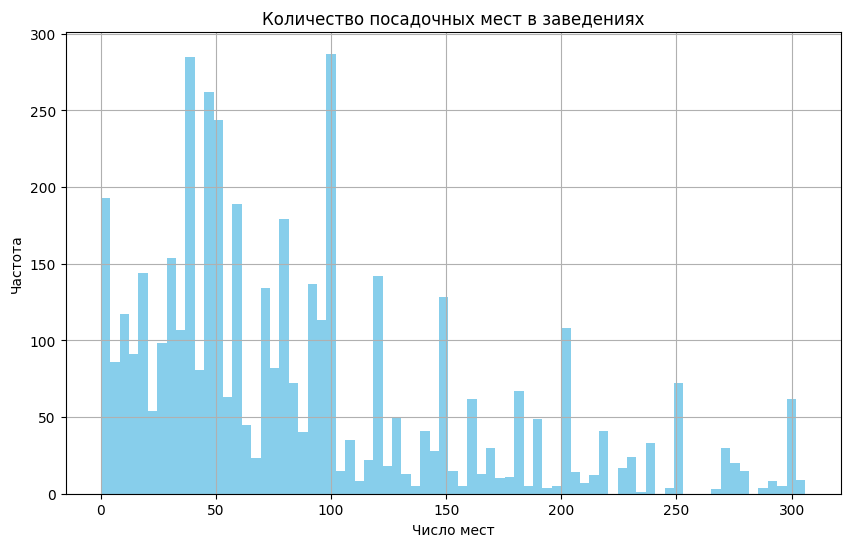

In [526]:
new_df['seats'].plot(kind= 'hist',
                 bins= 75,
                 title= 'Количество посадочных мест в заведениях',
                 color= 'skyblue',
                 figsize= (10, 6))

plt.xlabel('Число мест')
plt.ylabel('Частота')
plt.grid()
plt.show()

Гистограмма имеет правосимметричное распределение. Основной объем значений сфокусирован примерно между 0 и 250 посадочных мест

Строим диаграмму размаха значений в столбце `seats`

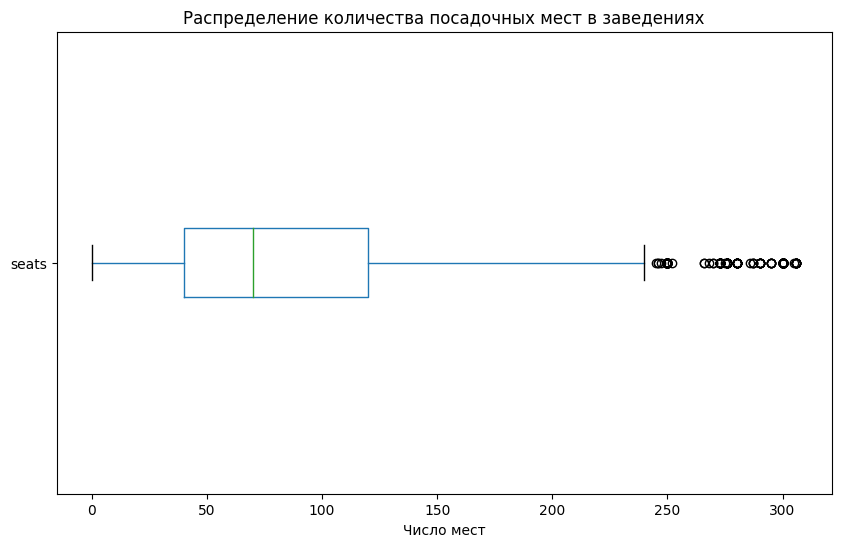

In [527]:
new_df['seats'].plot(kind= 'box',
                 vert= False,
                 title= 'Распределение количества посадочных мест в заведениях',
                 figsize= (10, 6))

plt.xlabel('Число мест')
plt.show()

На диаграмме размаха видны единичные выбросы в сторону аномально больших значений. Что впрочем тажке может быть связано со спецификой некоторых заведений города Москвы

Выведем медианные и средние значения посадочных мест в разрезе категорий объектов ОП по отфильтрованному датасету `df_outfliers_filtered`

In [528]:
cat_se = new_df.groupby('category')['seats'].agg(['median', 'mean']).sort_values(by = 'mean', ascending=False)

cat_se

,median,mean
category,,
ресторан,80.0,99.814226
"бар,паб",80.0,94.694253
кофейня,70.0,89.962079
быстрое питание,60.0,85.740299
столовая,72.0,81.375796
булочная,48.5,79.763889
пиццерия,50.0,79.014634
кафе,55.5,78.379518


Так как распределение значений посадочных мест имеет крайне неравномерный вид, то наиболее типичным числом посадочных мест по категориям заведений будем считать медианное значение

Отобразим распределение медианного значения посадочных мест по категориям заведений общественного питания

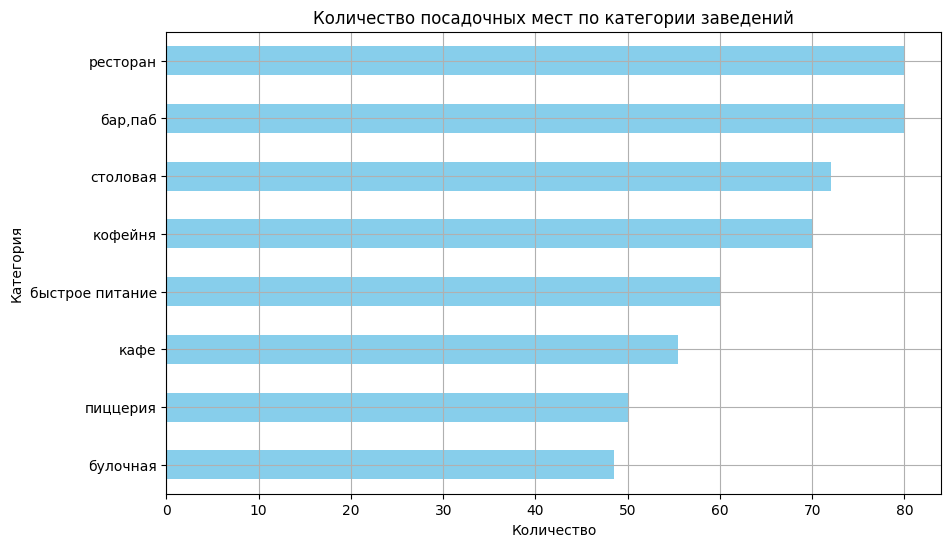

In [529]:
new_df.groupby('category')['seats'].median().sort_values(ascending=True).plot(kind= 'barh',
            x= 'category',
            title= 'Количество посадочных мест по категории заведений',
            xlabel= 'Категория',
            color= 'skyblue',
            figsize= (10, 6))

plt.xlabel('Количество')
plt.grid()
plt.show()

Вывод:<br>
Если убрать аномальные значения и выбросы.
- Максимальное количество мест — в категории "ресторан" (80 места).
- Минимальное количество мест — в категории "булочная" (48 мест).

В заведениях типа "бар, паб" и "быстрое питание" количество мест примерно одинаковое (около 80), что делает эти заведения одними из самых вместительных после ресторанов.

Заведения вроде "булочной", "кофейни" и "столовой" имеют схожее среднее количество мест (около 48-55).

---

### Задача 5

Исследуем рейтинг заведений. Визуализируем распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

Выведем средний рейтинг для каждой категории заведений

In [530]:
df_rating = df.groupby('category', as_index= False)['rating'].mean().round(2).sort_values(by= 'rating', ascending= False)

df_rating

,category,rating
0,"бар,паб",4.39
5,пиццерия,4.30
6,ресторан,4.29
4,кофейня,4.28
1,булочная,4.27
7,столовая,4.21
3,кафе,4.12
2,быстрое питание,4.05


И отобразим на линейчатой диаграмме

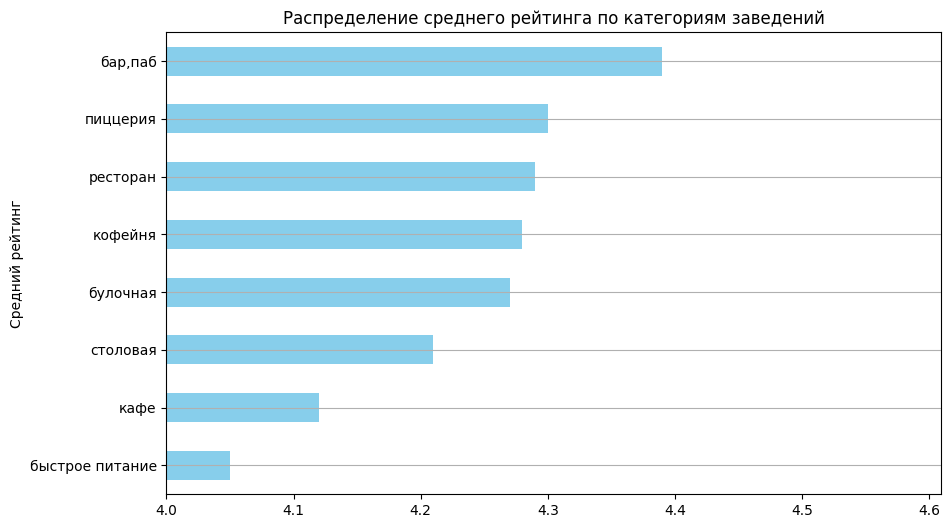

In [531]:
df_rating.groupby('category')['rating'].mean().sort_values(ascending=True).plot(kind= 'barh',
              title= 'Распределение среднего рейтинга по категориям заведений',
              xlabel= 'Средний рейтинг',
              ylabel= 'Категория',
              color= 'skyblue',
              rot= 0,
              figsize= (10, 6),
              xlim = 4,
              x= 'category')

plt.grid(axis= 'y')
plt.show()

Вывод:<br>
Усреднённые рейтинги для разных типов заведений варьируются незначительно. Разница между максимальным рейтингом (ресторан — 4.37) и минимальным (булочная — 4.17) составляет всего 0.20 балла. 


---

### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений? Построим и визуализируеме матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберем самую сильную связь и проверим её.

Создадим матрицу корреляции данных `category`, `district`, `chain`, `seats`, `price`, `is_24_7`, `rating` и построим на ее основе тепловую карту для признака `rating`

interval columns not set, guessing: ['chain', 'seats', 'rating']


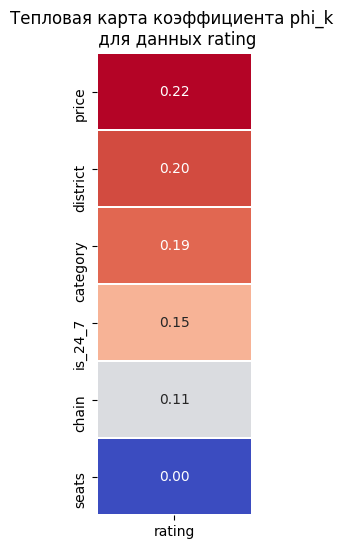

In [532]:
# Вычисляем корреляционную матрицу с использованием phi_k
corr_matrix = df[['category', 'district', 'chain', 'seats', 'price',
                         'is_24_7', 'rating']].phik_matrix()

plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
data_heatmap = corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')

# Выводим график
plt.show()

Вывод:
- Цена» (коэффициент корреляции равен 0.220295) -  наиболее сильная корреляция.
- Категория (коэффициент корреляции 0.208056) — также показывает заметную корреляцию с рейтингом.
- Район (коэффициент корреляции 0.185866) — корреляция чуть меньше, но тоже существенна. 
- Сеть (коэффициент корреляции 0.151431),
- Работа круглосуточно (коэффициент корреляции 0.124523),
- Количество мест (коэффициент корреляции 0.000000) — судя по всему, практически не коррелируют с рейтингом.

Самые сильные корреляции с рейтингом заведения наблюдаются с переменными «цена» и «категория». Эти факторы оказывают наибольшее влияние на формирование рейтинга заведения.

Проверим самую сильную связь `rating` и `price`.
Оценим плотность вероятности с помощью кривых KDE для рейтинга по каджой ценовой категории заведений

In [533]:
df['price']=df['price'].astype('object').fillna('нет данных')

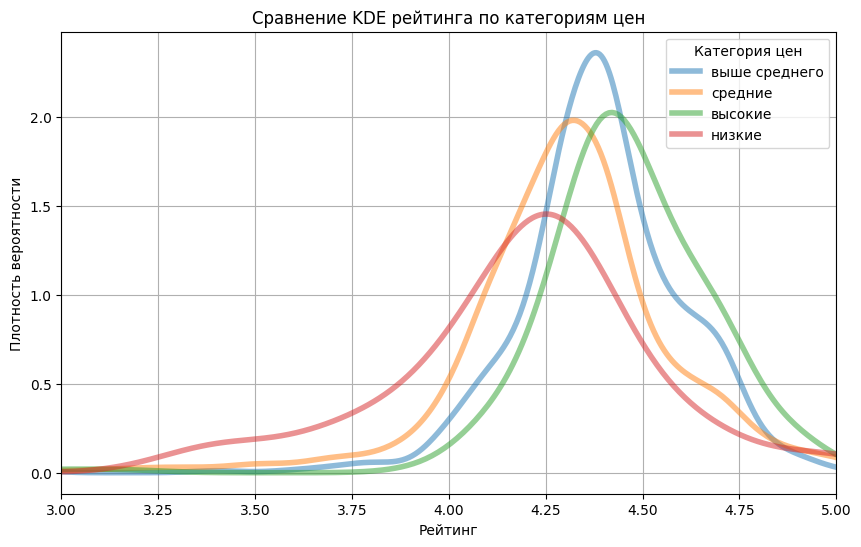

In [534]:
plt.figure(figsize=(10, 6))

for i in df['price'].unique():
    if i == 'нет данных':
        continue
    df.loc[df['price'] == i, 'rating'].plot(
        kind='kde',
        alpha=0.5,
        label=f'{i}',
        legend=True,
        xlim=[3,5],
        linewidth=4)
    
plt.title(f'Сравнение KDE рейтинга по категориям цен')
plt.xlabel('Рейтинг')
plt.ylabel('Плотность вероятности')

plt.legend(title='Категория цен')
plt.grid()
plt.show()

Отслеживается корреляция между ценовой категорией и рейтингом заведения: чем выше ценовая категория заведения ОП, тем выше его пиковый рейтинг и тем меньше диапазон значений рейтинга

---

### Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводим подходящими визуализациями.

Создадим сводную таблицу включающую название сетевого заведения, его категорию, число объектов и средний рейтинг

In [535]:
pivot_chain_est =  pd.pivot_table(df[df['chain']== 1],
                             index=['name', 'category'],
                             values=['id','rating'],
                             aggfunc={'id':'count','rating':'mean'}).sort_values(by='id', ascending=False) 
pivot_chain_est.head(15)

,,id,rating
name,category,,
шоколадница,кофейня,119,4.178151
домино'с пицца,пиццерия,76,4.169737
додо пицца,пиццерия,74,4.286486
one price coffee,кофейня,71,4.064789
яндекс лавка,ресторан,69,3.872464
cofix,кофейня,65,4.075385
prime,ресторан,49,4.114286
кофепорт,кофейня,42,4.147619
кулинарная лавка братьев караваевых,кафе,39,4.394872


Построим ТОП - 15 наиболее популярных заведений по их численности

In [536]:
df_chain = (df[df['chain']== 1])
# Группировка по столбцу 'Category' и суммирование значений
grouped_df = df_chain.groupby(['name']).agg({'id': 'count', 
                                             'rating': 'mean'}).reset_index()

# Сортировка по убыванию и выбор топ-15
top_15 = grouped_df.sort_values(by='id', ascending=False).head(15)

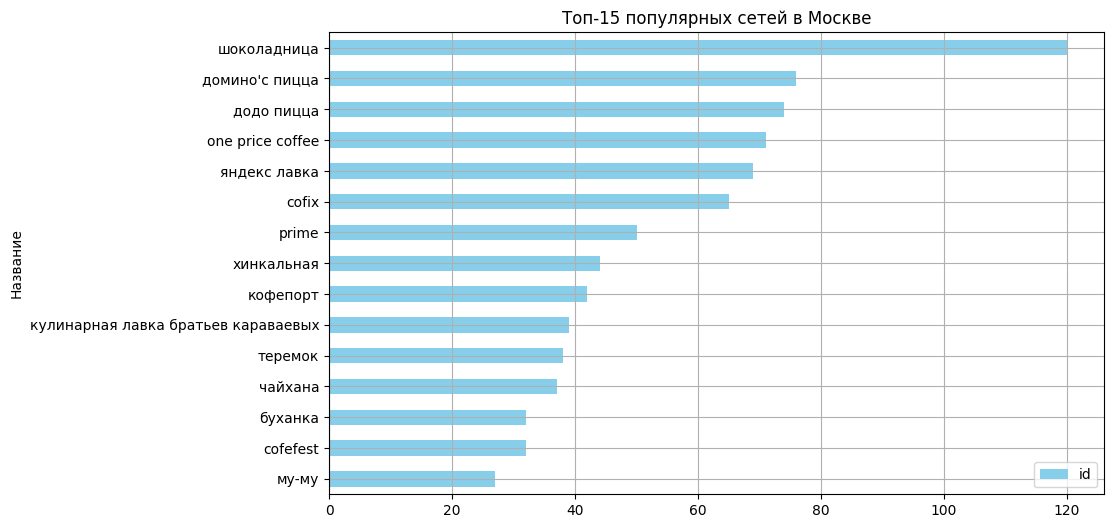

In [537]:
top_15.sort_values(by='id', ascending=True).plot(kind= 'barh',
              x= 'name',
              y= 'id',
              title= 'Топ-15 популярных сетей в Москве',
              xlabel= 'Название',
              ylabel= 'Количество',
              color= 'skyblue',
              rot= 0,
              figsize= (10, 6))

plt.grid()
plt.show()

Построим ТОП - 15 наиболее популярных заведений по их рейтингу

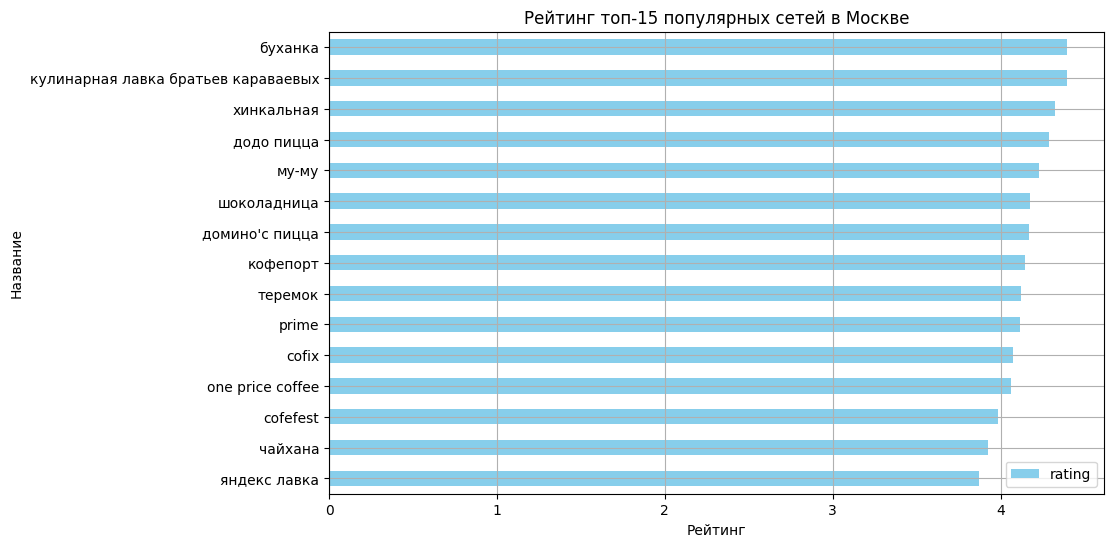

In [538]:
top_15.sort_values(by='rating', ascending=True).plot(kind= 'barh',
                    y= 'rating',
                    x= 'name',
                    title= 'Рейтинг топ-15 популярных сетей в Москве',
                    figsize= (10, 6),
                    color= 'skyblue')

plt.ylabel('Название')
plt.xlabel('Рейтинг')
plt.grid()
plt.show()

Вывод:<br>
Наиболее распространенными являются кофейни и пиццерии, такие как "Шоколадница", "Додо Пицца" и "Домино'с Пицца". Рестораны также занимают значительную долю рынка, особенно такие сети, как "Теремок" и "Тануки". Бар/пабы представлены в меньшей степени, но также имеют свою аудиторию.


Исследуем топ 5 категорий заведений ОП

In [539]:
# Группировка по столбцу 'Category' и суммирование значений
group_cat_df = df_chain.groupby('category')['id'].count().reset_index()
# Сортировка по убыванию и выбор топ-15
top_5_cat = group_cat_df.sort_values(by='id', ascending=False).head(5)

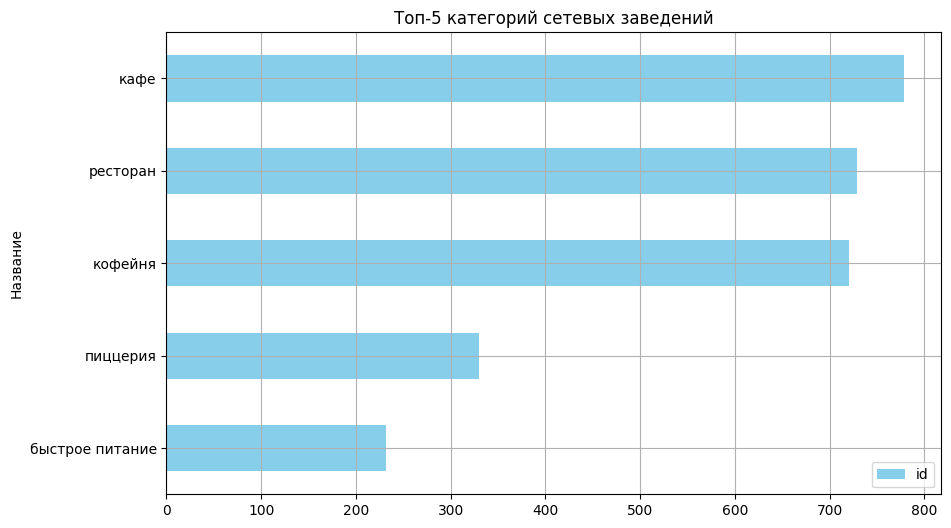

In [540]:
top_5_cat.sort_values(by='id', ascending=True).plot(kind= 'barh',
              x= 'category',
              y= 'id',
              title= 'Топ-5 категорий сетевых заведений',
              xlabel= 'Название',
              ylabel= 'Количество',
              color= 'skyblue',
              rot= 0,
              figsize= (10, 6))

plt.grid()
plt.show()

Самые популярные категории заведений: `кафе` (779), `рестораны` (729) и `кофейни` (720). В скобках число сетевых заведений в данной категории

---

### Задача 8

Изучить вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализировать цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводить подходящими визуализациями.


Выводим общую информацию по среднему чеку в разрезе округов Москвы

In [541]:
df_dist = df.groupby('district', 
                     as_index= False)['middle_avg_bill'].mean().sort_values(by= 'middle_avg_bill',
                                                                                     ascending= False)

df_dist

,district,middle_avg_bill
5,Центральный административный округ,1191.057547
1,Западный административный округ,1053.22549
2,Северный административный округ,927.959627
8,Южный административный округ,834.398089
4,Северо-Западный административный округ,822.22293
0,Восточный административный округ,820.626923
7,Юго-Западный административный округ,792.561702
3,Северо-Восточный административный округ,716.611296
6,Юго-Восточный административный округ,654.097938


Построим линейчатую диаграмму с сортировкой от большего к меньшему значениям среднего чека

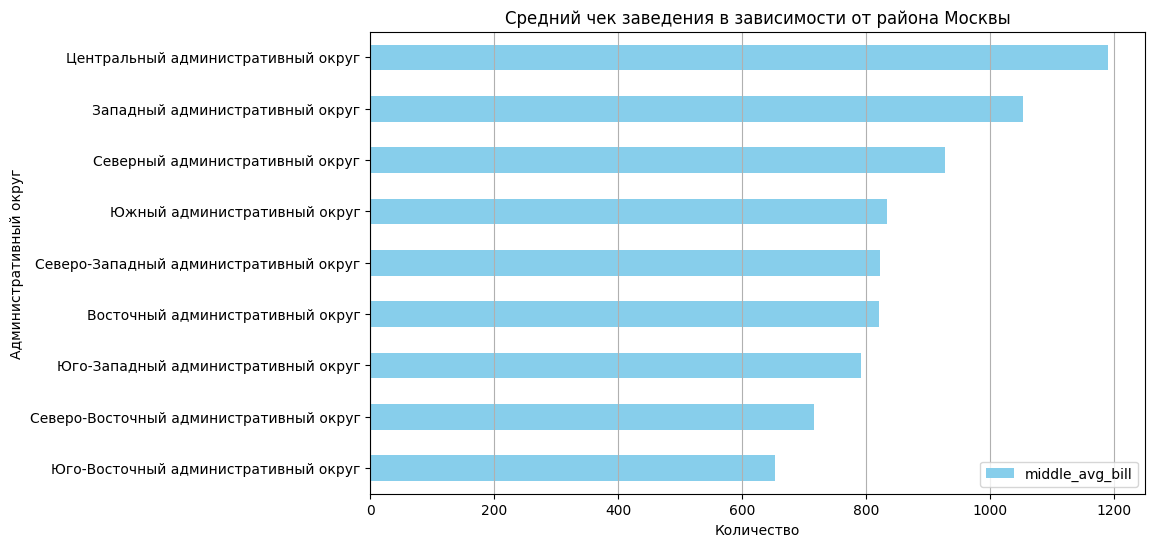

In [542]:
df_dist.sort_values(by= 'middle_avg_bill', ascending= True).plot(kind= 'barh',
            title= 'Средний чек заведения в зависимости от района Москвы',
            figsize= (10, 6),
            color= 'skyblue',
            x= 'district')

plt.ylabel('Административный округ')
plt.xlabel('Количество')
plt.grid(axis= 'x')
plt.show()

Вывод:<br>
Цены в Центральном административном округе (ЦАО) значительно выше, чем в остальных административных округах Москвы. ЦАО имеет цену 1191.06, что заметно больше всех остальных округов. 

- ЦАО vs Юго-Восточный АО — разница составляет около 537 единиц (1191.06 - 654.10). Это самое большое падение цен среди представленных округов.
- ЦАО vs Западный АО — цена в ЦАО почти на 138 единиц выше, чем в ЗАО (1191.06 - 1053.23).


Условно поделим округа Москвы на 2 группы:

`высокие по среднему чеку`: 
- центральный административный округ,
- западный административный округ,
- северный административный округ,
- южный административный округ	

`низкие по среднему чеку`:
- северо-западный административный округ	
- восточный административный округ	
- юго-западный административный округ	
- северо-восточный административный округ	
- юго-восточный административный округ	

Построим для каждой группы плотности распределения значений среднего чека

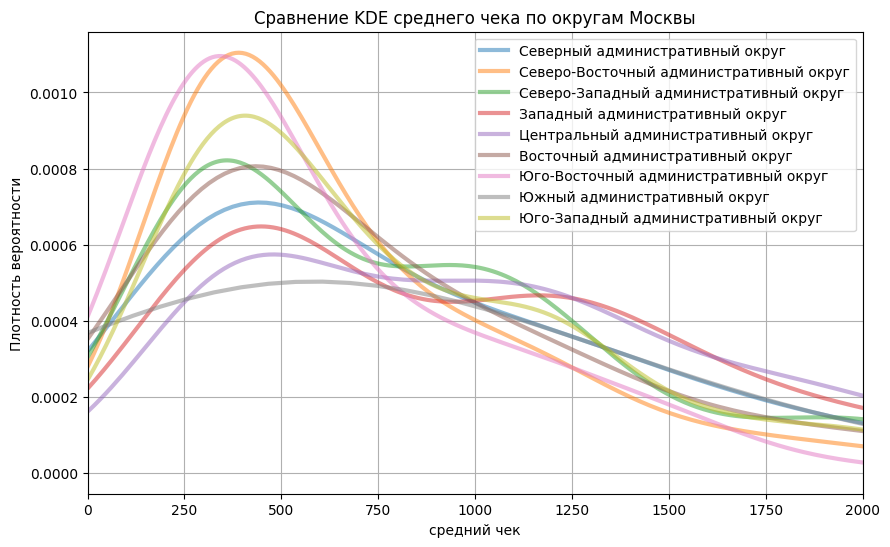

In [543]:
plt.figure(figsize=(10, 6))

for i in df['district'].unique():
    if (i == 'юго-восточный административный округ') or (i == 'северо-восточный административный округ')or (i == 'юго-западный административный округ') or (i == 'восточный административный округ') or (i== 'северо-западный административный округ'):
        continue
    df.loc[df['district'] == i, 'middle_avg_bill'].plot(
        kind='kde',
        alpha=0.5,
        label=f'{i}',
        xlim=[0,2000],
        legend=True,
        linewidth=3)
    
plt.title(f'Сравнение KDE среднего чека по округам Москвы')
plt.xlabel('средний чек')
plt.ylabel('Плотность вероятности')

plt.grid()
plt.show()

Как видно для высокой группы характерен большой разброс значений среднего чека. Что говорит о большом разнообразии заведений и цен и их большем количестве, а также близость к центру как выяснилось из предыдущего анализа коррелирует с повышением цены.
Для низкой группы значения более сфокусированы около максимума, то есть меньшее разнообразие и удаленность от центра делают значения среднего чека меньше с меньшим разбросом.

In [545]:
df_middle_avg_bill = df.groupby('district', 
                                as_index= False)['middle_avg_bill'].agg(['mean', 
                                                                         'median']).sort_values(by= 'mean', ascending= False)

df_middle_avg_bill.sort_values(by= 'mean', ascending= False)

,mean,median
district,,
Центральный административный округ,1191.057547,1000.0
Западный административный округ,1053.22549,1000.0
Северный административный округ,927.959627,650.0
Южный административный округ,834.398089,500.0
Северо-Западный административный округ,822.22293,700.0
Восточный административный округ,820.626923,575.0
Юго-Западный административный округ,792.561702,600.0
Северо-Восточный административный округ,716.611296,500.0
Юго-Восточный административный округ,654.097938,450.0


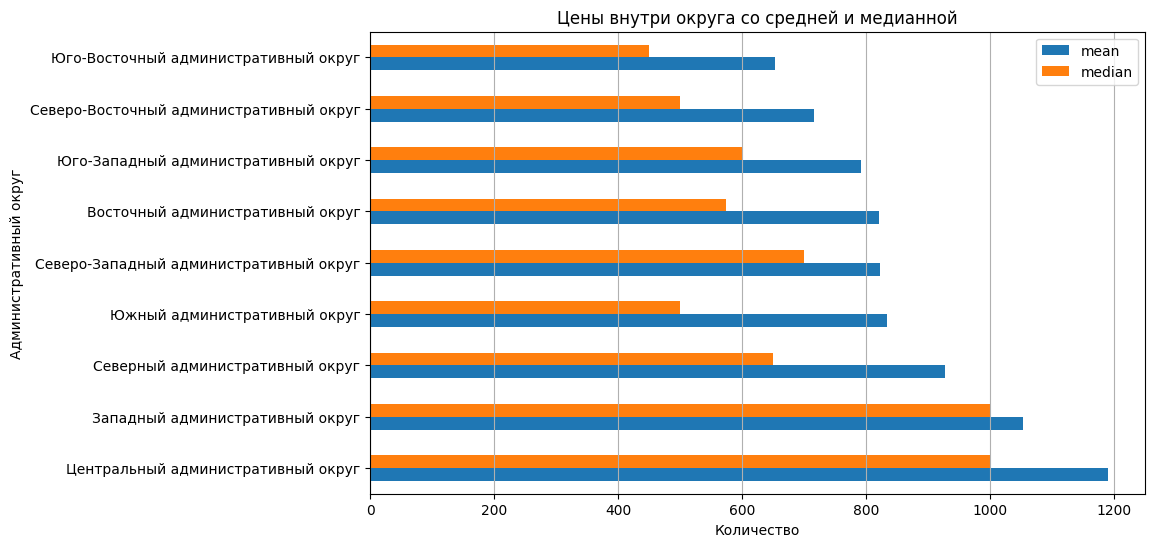

In [546]:
df_middle_avg_bill.plot(kind= 'barh',
                        figsize= (10, 6),
                        title= 'Цены внутри округа со средней и медианной')

plt.ylabel('Административный округ')
plt.xlabel('Количество')
plt.grid(axis= 'x')
plt.show()

---

### Промежуточный вывод


Полученные данные позволяют сделать несколько важных выводов о состоянии рынка общественного питания:

1. Популярность основных форматов
  - Рестораны, кофейни и кафе являются самыми многочисленными типами заведений. Это отражает широкий спрос на различные варианты досуга и перекуса.
  - Специализированные заведения, такие как бары/пабы и пиццерии, также пользуются спросом, хотя их число меньше.
  - Менее популярные форматы, такие как столовые и заведения быстрого питания, присутствуют, но их доля значительно ниже.
2. Преобладание несетевых заведений
  - Несетевые заведения заметно превосходят сетевые по числу представленных точек. Это говорит о высокой конкуренции и разнообразии предложений на рынке.
  - Тем не менее, сетевые заведения играют важную роль, особенно в сегменте пиццерий, где они доминируют благодаря таким известным брендам, как "Додо Пицца" и "Домино'с Пицца".
3. Уровень удовлетворённости клиентов
  - Средний рейтинг заведений практически одинаков для всех категорий, разница составляет лишь 0.20 баллов. Это значит, что клиенты одинаково довольны услугами независимо от формата заведения.
  - Небольшие отличия в рейтинге связаны скорее с субъективностью оценок, чем с существенными различиями в качестве обслуживания.
4. Количество посадочных мест
  - Рестораны лидируют по среднему количеству мест, предлагая наибольшую вместимость.
  - Заведения типа баров и быстрого питания также предлагают достаточно пространства для посетителей, что важно для их формата.
  - Кафе, кофейни и булочные имеют меньшее количество мест, что соответствует их концепции уютных и компактных пространств.
  
5. Географическая зависимость цен:
  - Стоимость услуг снижается по мере удаления от центра города.
  - Сильные корреляции с рейтингом заведения наблюдаются с факторами цены и категории. Таким образом, цена является одним из ключевых факторов, влияющих на восприятие заведения клиентами.

Основные выводы:
- Потребители стремятся к разнообразию, выбирая между ресторанами, кофейнями, кафе и специализированными заведениями.
- Несмотря на преобладание последних, сетевые заведения остаются значимыми игроками, особенно в сегментах пиццерий и ресторанов.
- Клиенты оценивают разные типы заведений почти одинаково, что говорит о высоком общем уровне сервиса.
- Чем дальше заведение расположено от центра, тем ниже его средняя цена, что создает возможность для более демократичных вариантов питания.


## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.


1. Общий обзор проделанной работы:
Проведен детальный анализ двух наборов данных: `rest_info.csv` и `rest_price.csv`. Данные были исследованы на предмет качества, наличие пропусков, дубликатов, распределения категорий заведений и особенностей заполнения отдельных столбцов. Особое внимание уделялось пропускам в значениях, поскольку это могло оказать существенное влияние на интерпретацию результатов.

Основные моменты анализа включают:

- Высокое количество пропусков в некоторых столбцах (`seats`, `price`, `avg_bill`, `middle_avg_bill`), что требует аккуратного подхода к обработке данных.
- Отсутствие полных дубликатов строк и уникальных идентификаторов, подтверждающих корректность записей.
- Проверка соответствия значений в столбце `middle_avg_bill` заданному условию показала соответствие ожиданий.

Также была проведена оценка популярности различных типов заведений, что позволило выявить наиболее распространенные категории, такие как `рестораны`, `кофейни` и `кафе`, а также зависимость средней стоимости услуги от удалённости от центра города.

2. Ответы на исследовательские вопросы, или главные выводы:
- Набор данных `rest_info.csv` обладает высоким качеством, однако `rest_price.csv` имеет значительные пропуски, особенно в столбцах `seats (43%)`, `price (60%)` и `middle_coffee_cup (94%)`. Это снижает точность анализа и требует осторожного подхода при интерпретации результатов.
- Рестораны, кофейни и кафе составляют основную массу представленных заведений, демонстрируя высокий спрос на различные типы общественного питания. Заведения быстрого питания и пиццерии также пользуются спросом, хотя их доли меньше.
- Средний рейтинг различных типов заведений варьируется незначительно, разница между максимальным и минимальным значением составляет всего 0.2 балла. Это указывает на общий высокий уровень удовлетворенности клиентов независимо от типа заведения.
- Сильные корреляции с рейтингом заведения наблюдаются с переменными `«цена»` и `«категория»`, что подчеркивает важность этих факторов в формировании общего впечатления клиента.
- Стоимость снижается с увеличением расстояния от центрального административного округа (ЦАО) до периферийных районов Москвы.

3. Рекомендации на основе анализа данных:
Обработка пропусков:
- Для столбцов с большим количеством пропусков рекомендуется использовать методы заполнения (например, медианное значение или интерполяция) либо исключение данных, чтобы избежать искажений в анализе.
- Важно учесть контекст каждого пропуска и принять решение о методике обработки индивидуально для каждой колонки.

Улучшение данных:
- Рекомендуется собирать дополнительные данные для заполнения пропусков, особенно для критически важных столбцов, таких как `seats`, `price` и `middle_coffee_cup`.
- Регулярно обновлять данные, чтобы поддерживать актуальность информации и минимизировать риск появления новых пропусков.

Маркетинговая стратегия:
- Учитывая сильную корреляцию между ценой и категорией заведения с рейтингом, стоит уделять особое внимание ценовой политике и позиционированию заведения на рынке.
- Продвигать сеть ресторанов и кофеен, учитывая их популярность среди потребителей, а также развивать предложения для специфичных ниш (например, пиццерии и булочные).

Анализ влияния местоположения:
- Рассмотреть возможность открытия новых точек в районах с низкой конкуренцией, где затраты на аренду помещений могут быть ниже, а потенциальная аудитория достаточно велика.
- Учитывать локальные предпочтения жителей разных округов при разработке маркетинговых стратегий.

Мониторинг удовлетворенности клиентов:
-Постоянный сбор отзывов и рейтингов позволит оперативно реагировать на изменения в предпочтениях клиентов и улучшать качество предоставляемых услуг.

Этот анализ позволяет заказчику получить полное представление о состоянии данных и потенциальных направлениях развития бизнеса в сфере общественного питания.